# Transfer Learning with CBAM Attention & Grad-CAM Explainability
This notebook implements a ResNet18 backbone with CBAM attention modules, extensive visualizations, and Grad-CAM explainability for breast histopathology classification.

In [1]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay


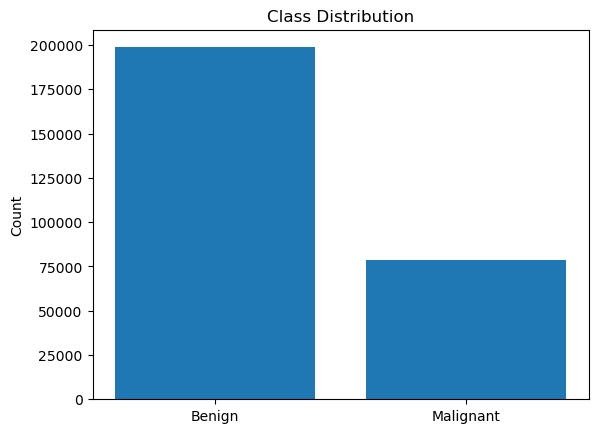

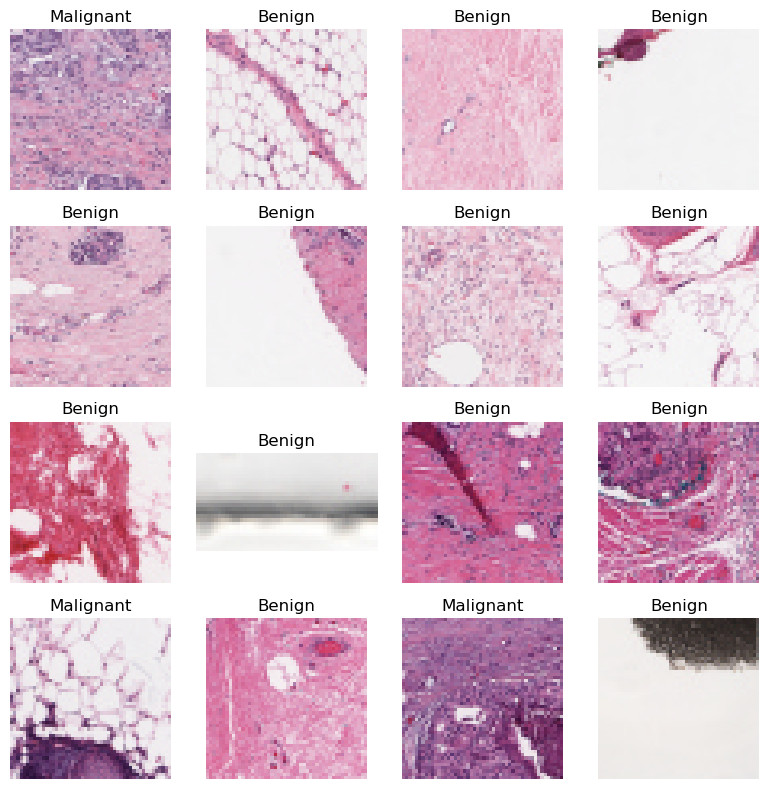

In [2]:
# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths, self.labels = [], []
        for patient in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient)
            if os.path.isdir(patient_path):
                for lbl in ['0','1']:
                    lbl_path = os.path.join(patient_path, lbl)
                    if os.path.isdir(lbl_path):
                        for img in os.listdir(lbl_path):
                            if img.endswith('.png'):
                                self.image_paths.append(os.path.join(lbl_path, img))
                                self.labels.append(int(lbl))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Load dataset & visualize class distribution
full_dataset = CustomDataset('Data')
counts = Counter(full_dataset.labels)
plt.bar(['Benign','Malignant'], [counts[0],counts[1]])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

# Sample images
samples = random.sample(range(len(full_dataset)), 16)
fig, axes = plt.subplots(4,4, figsize=(8,8))
for ax, idx in zip(axes.flatten(), samples):
    img = Image.open(full_dataset.image_paths[idx]).convert('RGB')
    lbl = full_dataset.labels[idx]
    ax.imshow(img)
    ax.set_title('Malignant' if lbl else 'Benign')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [3]:
# Train/Val Split & DataLoaders with Weighted Sampler
indices = list(range(len(full_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=full_dataset.labels, random_state=42)

train_dataset = Subset(CustomDataset('Data', transform=train_transform), train_idx)
val_dataset   = Subset(CustomDataset('Data', transform=val_transform), val_idx)

train_labels = [full_dataset.labels[i] for i in train_idx]
class_counts = [counts[i] for i in [0,1]]
weights = [1.0/class_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


In [4]:
# CBAM Modules
class ChannelAttention(nn.Module):
    def __init__(self, in_ch, ratio=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_ch, in_ch//ratio),
            nn.ReLU(),
            nn.Linear(in_ch//ratio, in_ch)
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        avg = self.avg_pool(x).view(b,c)
        maxp = self.max_pool(x).view(b,c)
        scale = torch.sigmoid(self.mlp(avg) + self.mlp(maxp)).view(b,c,1,1)
        return x * scale

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2,1,kernel_size=k,padding=(k-1)//2)
    def forward(self, x):
        avg = x.mean(dim=1,keepdim=True)
        maxp,_ = x.max(dim=1,keepdim=True)
        scale = torch.sigmoid(self.conv(torch.cat([avg,maxp],dim=1)))
        return x * scale

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

# Model Definition: ResNet18 + CBAM + Classifier
class ResNet18_CBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        # Freeze all except layer4 & fc
        for name, param in self.backbone.named_parameters():
            if not name.startswith('layer4') and not name.startswith('fc'):
                param.requires_grad = False
        self.cbam = CBAM(512)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,2)
        )
    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
        return self.fc(x)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = ResNet18_CBAM().to(device)

/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/imamahasan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:12<00:00, 3.62MB/s]


In [5]:
# Training Setup
train_label_list = [full_dataset.labels[i] for i in train_idx]
class_weights = torch.tensor([len(train_label_list)/counts[i] for i in [0,1]], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training Loop
num_epochs = 30
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    r_loss, r_corr, r_tot = 0,0,0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        r_loss += loss.item()*imgs.size(0)
        preds = out.argmax(1)
        r_corr += (preds==lbls).sum().item()
        r_tot += imgs.size(0)
    train_losses.append(r_loss/r_tot)
    train_accs.append(r_corr/r_tot)
    
    model.eval()
    v_loss, v_corr, v_tot = 0,0,0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            v_loss += loss.item()*imgs.size(0)
            preds = out.argmax(1)
            v_corr += (preds==lbls).sum().item()
            v_tot += imgs.size(0)
    val_losses.append(v_loss/v_tot)
    val_accs.append(v_corr/v_tot)

    if val_accs[-1] > best_acc:
        best_acc = val_accs[-1]
        torch.save(model.state_dict(), 'best_resnet_cbam.pth')
    scheduler.step(val_losses[-1])
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} Train Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} Val Acc: {val_accs[-1]:.4f}")


Epoch 1/30 | Train Loss: 0.2656 Train Acc: 0.8593 | Val Loss: 0.2844 Val Acc: 0.8608
Epoch 2/30 | Train Loss: 0.2360 Train Acc: 0.8756 | Val Loss: 0.3061 Val Acc: 0.8365
Epoch 3/30 | Train Loss: 0.2225 Train Acc: 0.8831 | Val Loss: 0.2699 Val Acc: 0.8651
Epoch 4/30 | Train Loss: 0.2121 Train Acc: 0.8881 | Val Loss: 0.2766 Val Acc: 0.8677
Epoch 5/30 | Train Loss: 0.1999 Train Acc: 0.8940 | Val Loss: 0.2701 Val Acc: 0.8724
Epoch 6/30 | Train Loss: 0.1919 Train Acc: 0.8995 | Val Loss: 0.3066 Val Acc: 0.8459
Epoch 7/30 | Train Loss: 0.1835 Train Acc: 0.9029 | Val Loss: 0.2724 Val Acc: 0.8891
Epoch 8/30 | Train Loss: 0.1640 Train Acc: 0.9140 | Val Loss: 0.2743 Val Acc: 0.8887
Epoch 9/30 | Train Loss: 0.1537 Train Acc: 0.9190 | Val Loss: 0.2869 Val Acc: 0.8959
Epoch 10/30 | Train Loss: 0.1479 Train Acc: 0.9236 | Val Loss: 0.2957 Val Acc: 0.8788
Epoch 11/30 | Train Loss: 0.1396 Train Acc: 0.9277 | Val Loss: 0.2782 Val Acc: 0.8840
Epoch 12/30 | Train Loss: 0.1269 Train Acc: 0.9348 | Val Loss: 

/var/folders/qk/szcdgwl97f98j7b69xpwh2200000gn/T/ipykernel_2652/2761054824.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_resnet_

              precision    recall  f1-score   support

      Benign       0.95      0.92      0.94     39748
   Malignant       0.82      0.87      0.84     15757

    accuracy                           0.91     55505
   macro avg       0.88      0.90      0.89     55505
weighted avg       0.91      0.91      0.91     55505



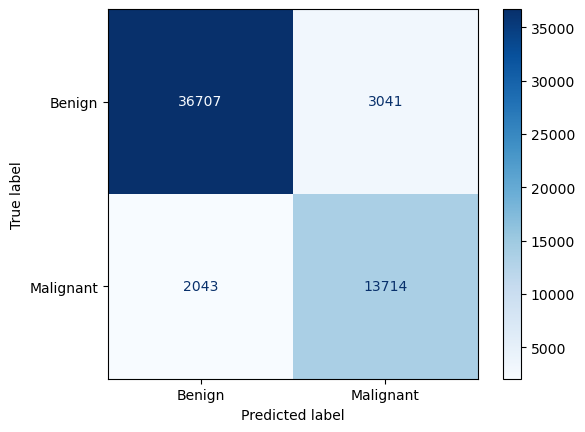

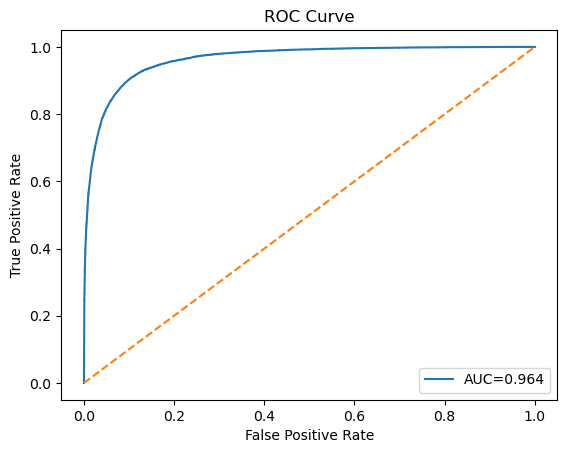

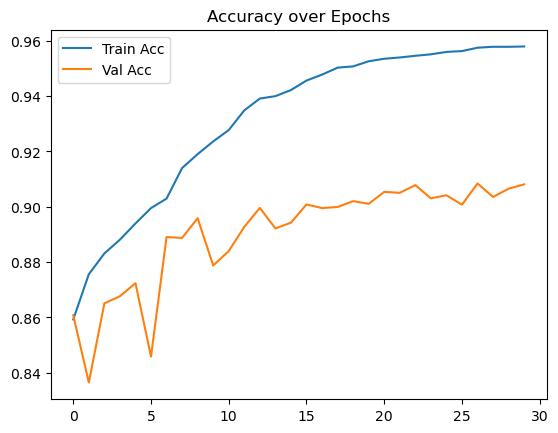

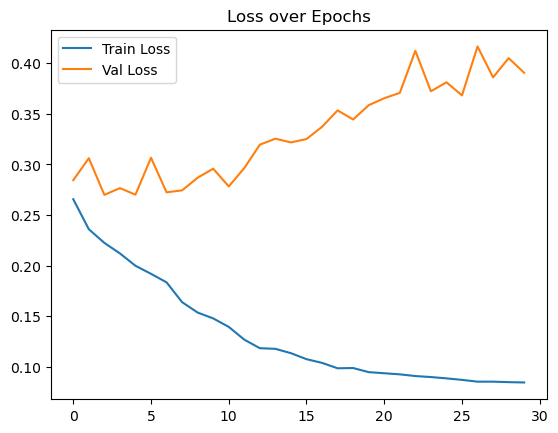

In [6]:
# Evaluation Metrics & Visualizations
model.load_state_dict(torch.load('best_resnet_cbam.pth'))
model.eval()

all_lbls, all_preds, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        probs = F.softmax(out,1)[:,1]
        preds = out.argmax(1)
        all_lbls.extend(lbls.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Classification Report
print(classification_report(all_lbls, all_preds, target_names=['Benign','Malignant']))

# Confusion Matrix
cm = confusion_matrix(all_lbls, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
disp.plot(cmap='Blues')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_lbls, all_probs)
auc = roc_auc_score(all_lbls, all_probs)
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Training Curves
plt.figure()
plt.plot(train_accs, label='Train Acc'); plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy over Epochs'); plt.legend(); plt.show()

plt.figure()
plt.plot(train_losses, label='Train Loss'); plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs'); plt.legend(); plt.show()


/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.11/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


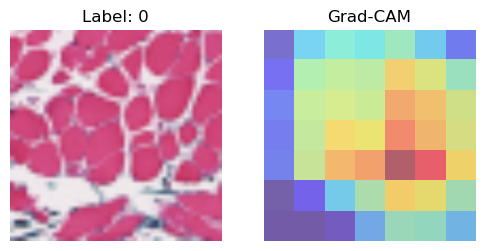

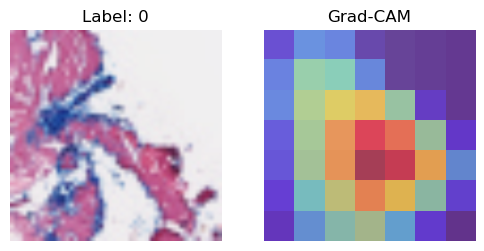

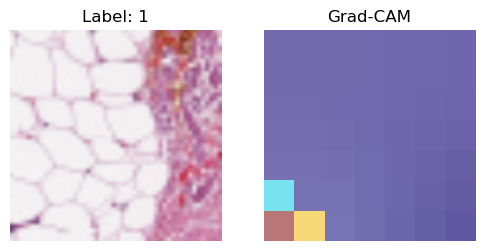

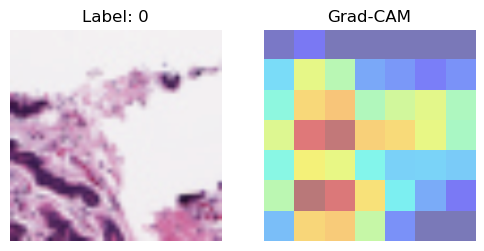

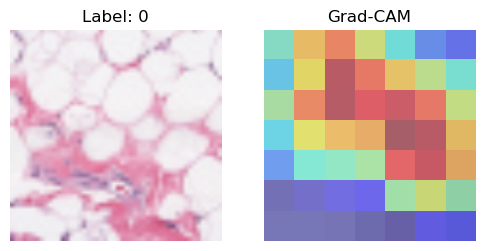

In [7]:
# Grad-CAM Implementation & Visualization
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.gradients = None; self.activations = None; self.handles = []
        self._register_hooks()
    def _register_hooks(self):
        def fwd_hook(_, __, out): self.activations = out.detach()
        def bwd_hook(_, __, grad): self.gradients = grad[0].detach()
        self.handles.append(self.target_layer.register_forward_hook(fwd_hook))
        self.handles.append(self.target_layer.register_backward_hook(bwd_hook))
    def generate_cam(self, img_tensor, cls=None):
        self.model.eval()
        out = self.model(img_tensor)
        if cls is None: cls = out.argmax(1).item()
        self.model.zero_grad(); out[0,cls].backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min())/(cam.max()-cam.min())
        return cam
    def remove(self):
        for h in self.handles: h.remove()

# Visualize
target_layer = model.backbone.layer4[-1].conv2
gradcam = GradCAM(model, target_layer)
for i in range(5):
    img, lbl = val_dataset[i]
    inp = img.unsqueeze(0).to(device)
    cam = gradcam.generate_cam(inp, cls=lbl)
    img_np = img.permute(1,2,0).numpy() * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_np = np.clip(img_np,0,1)
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1); plt.imshow(img_np); plt.title(f'Label: {lbl}'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img_np); plt.imshow(cam, cmap='jet', alpha=0.5); plt.title('Grad-CAM'); plt.axis('off')
    plt.show()
gradcam.remove()
